<a href="https://colab.research.google.com/github/stanislawWojtas/Przetwarzanie-Obraz-w-Cyfrowych/blob/main/06_context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Przetwarzanie wstępne. Filtracja kontekstowa.


### Cel:
- zapoznanie z pojęciem kontekstu / filtracji kontekstowej,
- zapoznanie z pojęciem konwolucji (splotu),
- zapoznanie z wybranymi filtrami:
	- filtry liniowe dolnoprzepustowe:
		- filtr uśredniający,
		- filtr Gaussa.
	- filtry nielinowe:
		- mediana,
		- mediana dla obrazów kolorowych.
	- filtry liniowe górnoprzepustowe:
			- laplasjan,
			- operator Robersta, Prewitta, Sobela.
- zadanie domowe: adaptacyjna filtracja medianowa.

### Filtry liniowe uśredniające (dolnoprzepustowe)

Jest to podstawowa rodzina filtrów stosowana w cyfrowym przetwarzaniu obrazów.
Wykorzystuje się je w celu "rozmazania" obrazu i tym samym redukcji szumów (zakłóceń) na obrazie.
Filtr określony jest przez dwa parametry: rozmiar maski (ang. _kernel_) oraz wartości współczynników maski.

Warto zwrócić uwagę, że omawiane w niniejszym rozdziale operacje generują nową wartość piksela na podstawie pewnego fragmentu obrazu (tj. kontekstu), a nie jak operacje punktowe tylko na podstawie jednego piksela.


1. Wczytaj obraz _plansza.png_.
W dalszej części ćwiczenia sprawdzenie działania filtracji dla innych obrazów sprowadzi się do wczytania innego pliku.

2. Podstawowa funkcja to `cv2.filter2D`  - realizacja filtracji konwolucyjnej.
   Proszę sprawdzić jej dokumentację i zwrócić uwagę na obsługę problemu brzegowego (na krawędziach istnieją piksele dla których nie da się wyznaczyć otoczenia).

  Uwaga. Problem ten można też rozwiązać z użyciem funkcji `signal.convolve2d` z biblioteki _scipy_ (`from scipy import signal`).

3. Stwórz podstawowy filtr uśredniający o rozmiarze $3 \times 3$ -- za pomocą funkcji `np.ones`. Wykonaj konwolucję na wczytanym obrazie. Na wspólnym rysunku wyświetl obraz oryginalny, po filtracji oraz moduł z różnicy.

4. Przeanalizuj otrzymane wyniki. Jakie elementy zawiera obraz "moduł z różnicy"? Co na tej podstawie można powiedzieć o filtracji dolnoprzepustowej?

In [120]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np
from scipy import signal

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/06_Context/'

fileNames = ["jet.png", "kw.png", "moon.png", "lenaSzum.png", "lena.png", "plansza.png"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)



(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

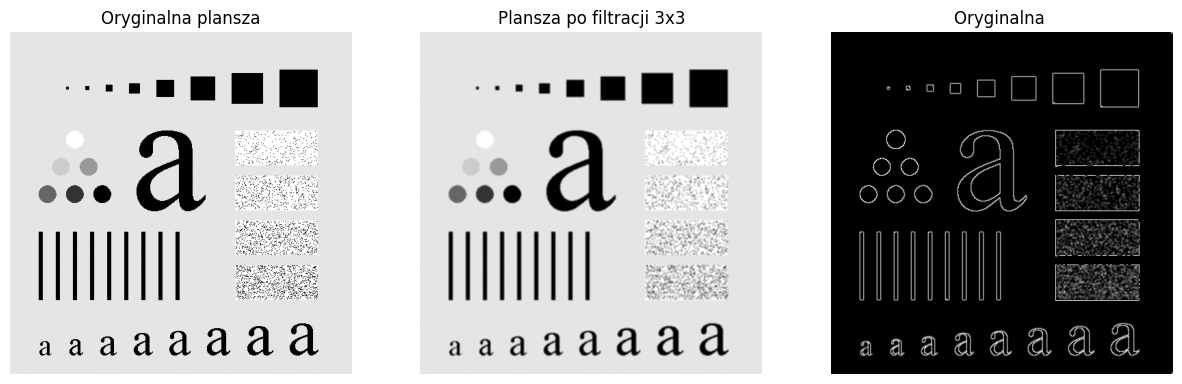

In [121]:
plansza = cv2.imread("plansza.png" ,cv2.IMREAD_GRAYSCALE)
kernel1 = np.ones((3, 3), np.float32) / 9

plansza_filtered = np.zeros_like(plansza)
plansza_filtered = cv2.filter2D(plansza, -1, kernel1)
plansza_diff = np.abs(plansza - plansza_filtered)

plt.figure(figsize=(15,10))
plt.subplot(1, 3, 1)
plt.imshow(plansza, cmap='gray')
plt.title("Oryginalna plansza")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(plansza_filtered, cmap='gray')
plt.title("Plansza po filtracji 3x3")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(plansza_diff, cmap='gray')
plt.title("Oryginalna ")
plt.axis("off")

5. Na wspólnym rysunku wyświetl wyniki filtracji uśredniającej z oknem o rozmiarze 3, 5, 9, 15 i 35.
Wykorzystaj polecenie `plt.subplot`.
Przeanalizuj wpływ rozmiaru maski na wynik.

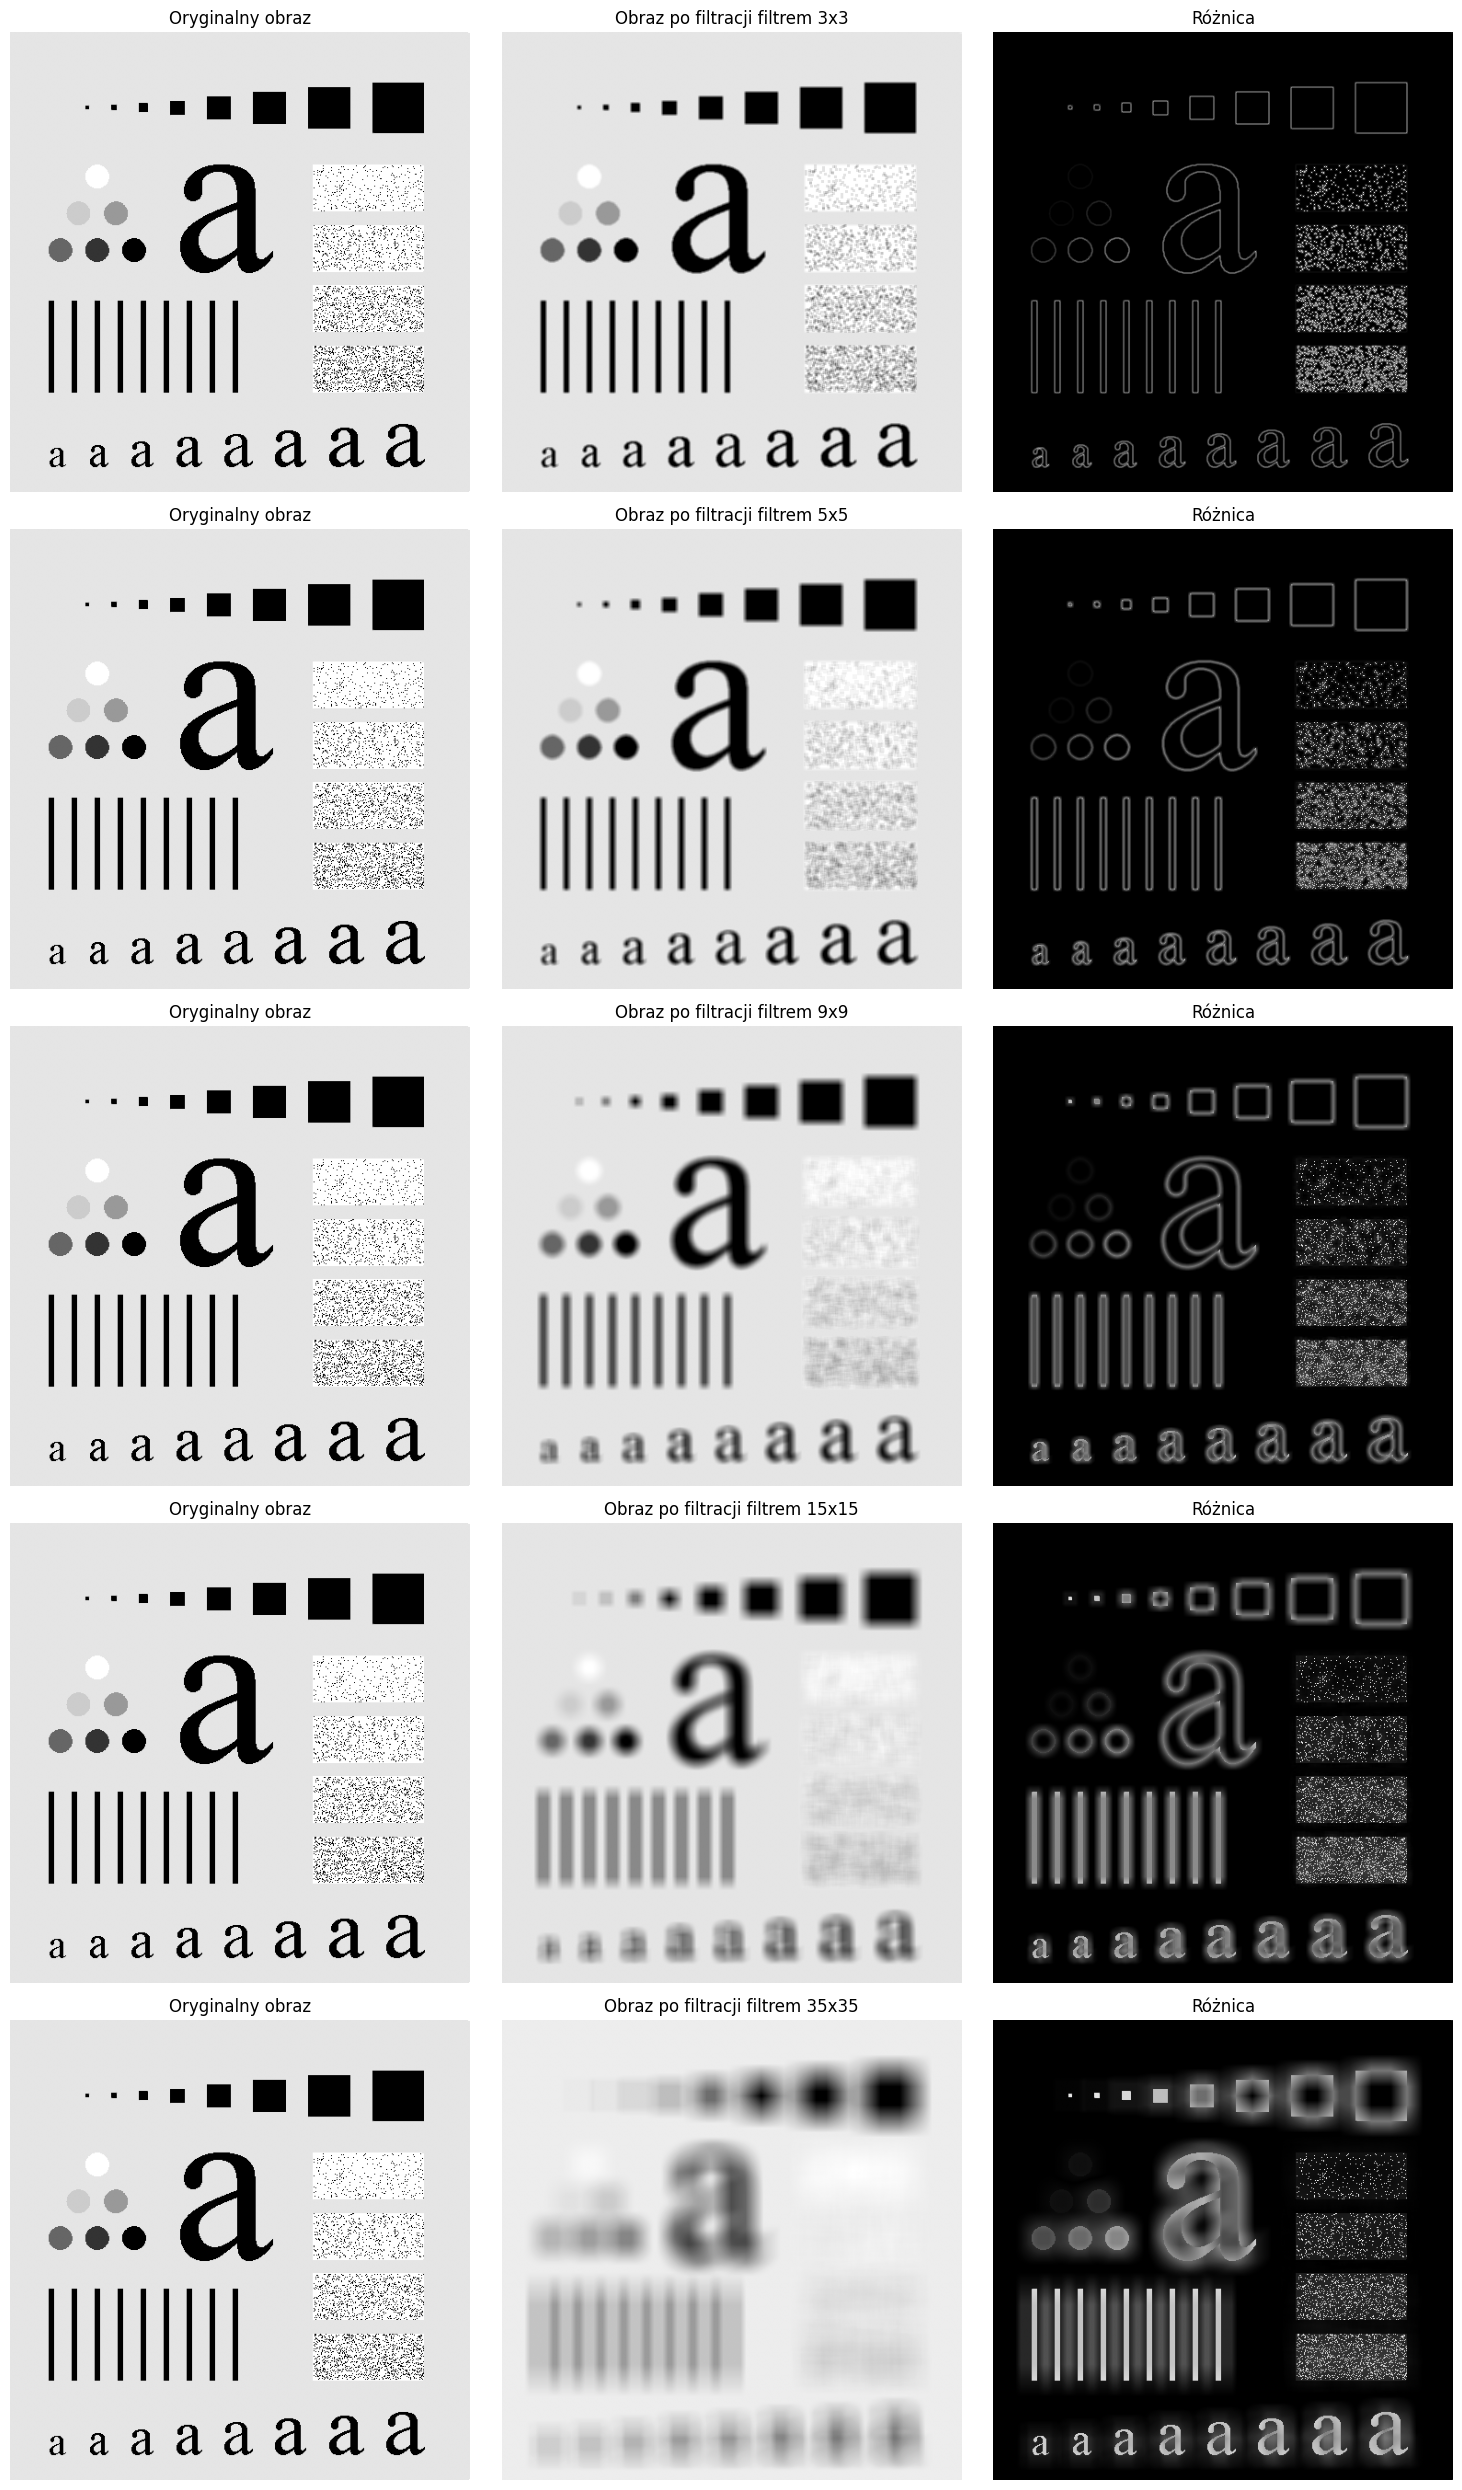

In [122]:
kernel_sizes = [3, 5, 9, 15, 35]
def plot_filtered_images(img, kernel_sizes):
  plt.figure(figsize=(15, 5 * len(kernel_sizes)))

  for i, size in enumerate(kernel_sizes):
    kernel = np.ones((size, size), np.float32) / (size*size)
    img_filtered = cv2.filter2D(img, -1, kernel)
    img_diff = img.astype(np.float32) - img_filtered.astype(np.float32)
    img_diff = np.abs(img_diff).astype(np.uint8)

    plt.subplot(len(kernel_sizes), 3, i * 3 + 1)
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Oryginalny obraz")

    plt.subplot(len(kernel_sizes), 3, i * 3 + 2)
    plt.imshow(img_filtered, cmap='gray')
    plt.axis("off")
    plt.title(f'Obraz po filtracji filtrem {size}x{size}')

    plt.subplot(len(kernel_sizes), 3, i * 3 + 3)
    plt.imshow(img_diff, cmap='gray')
    plt.axis("off")
    plt.title("Różnica")

  plt.tight_layout()
  plt.show()

plot_filtered_images(plansza, kernel_sizes)

6. Wczytaj obraz _lena.png_.
Zaobserwuj efekty filtracji dolnoprzepustowej dla obrazu rzeczywistego.

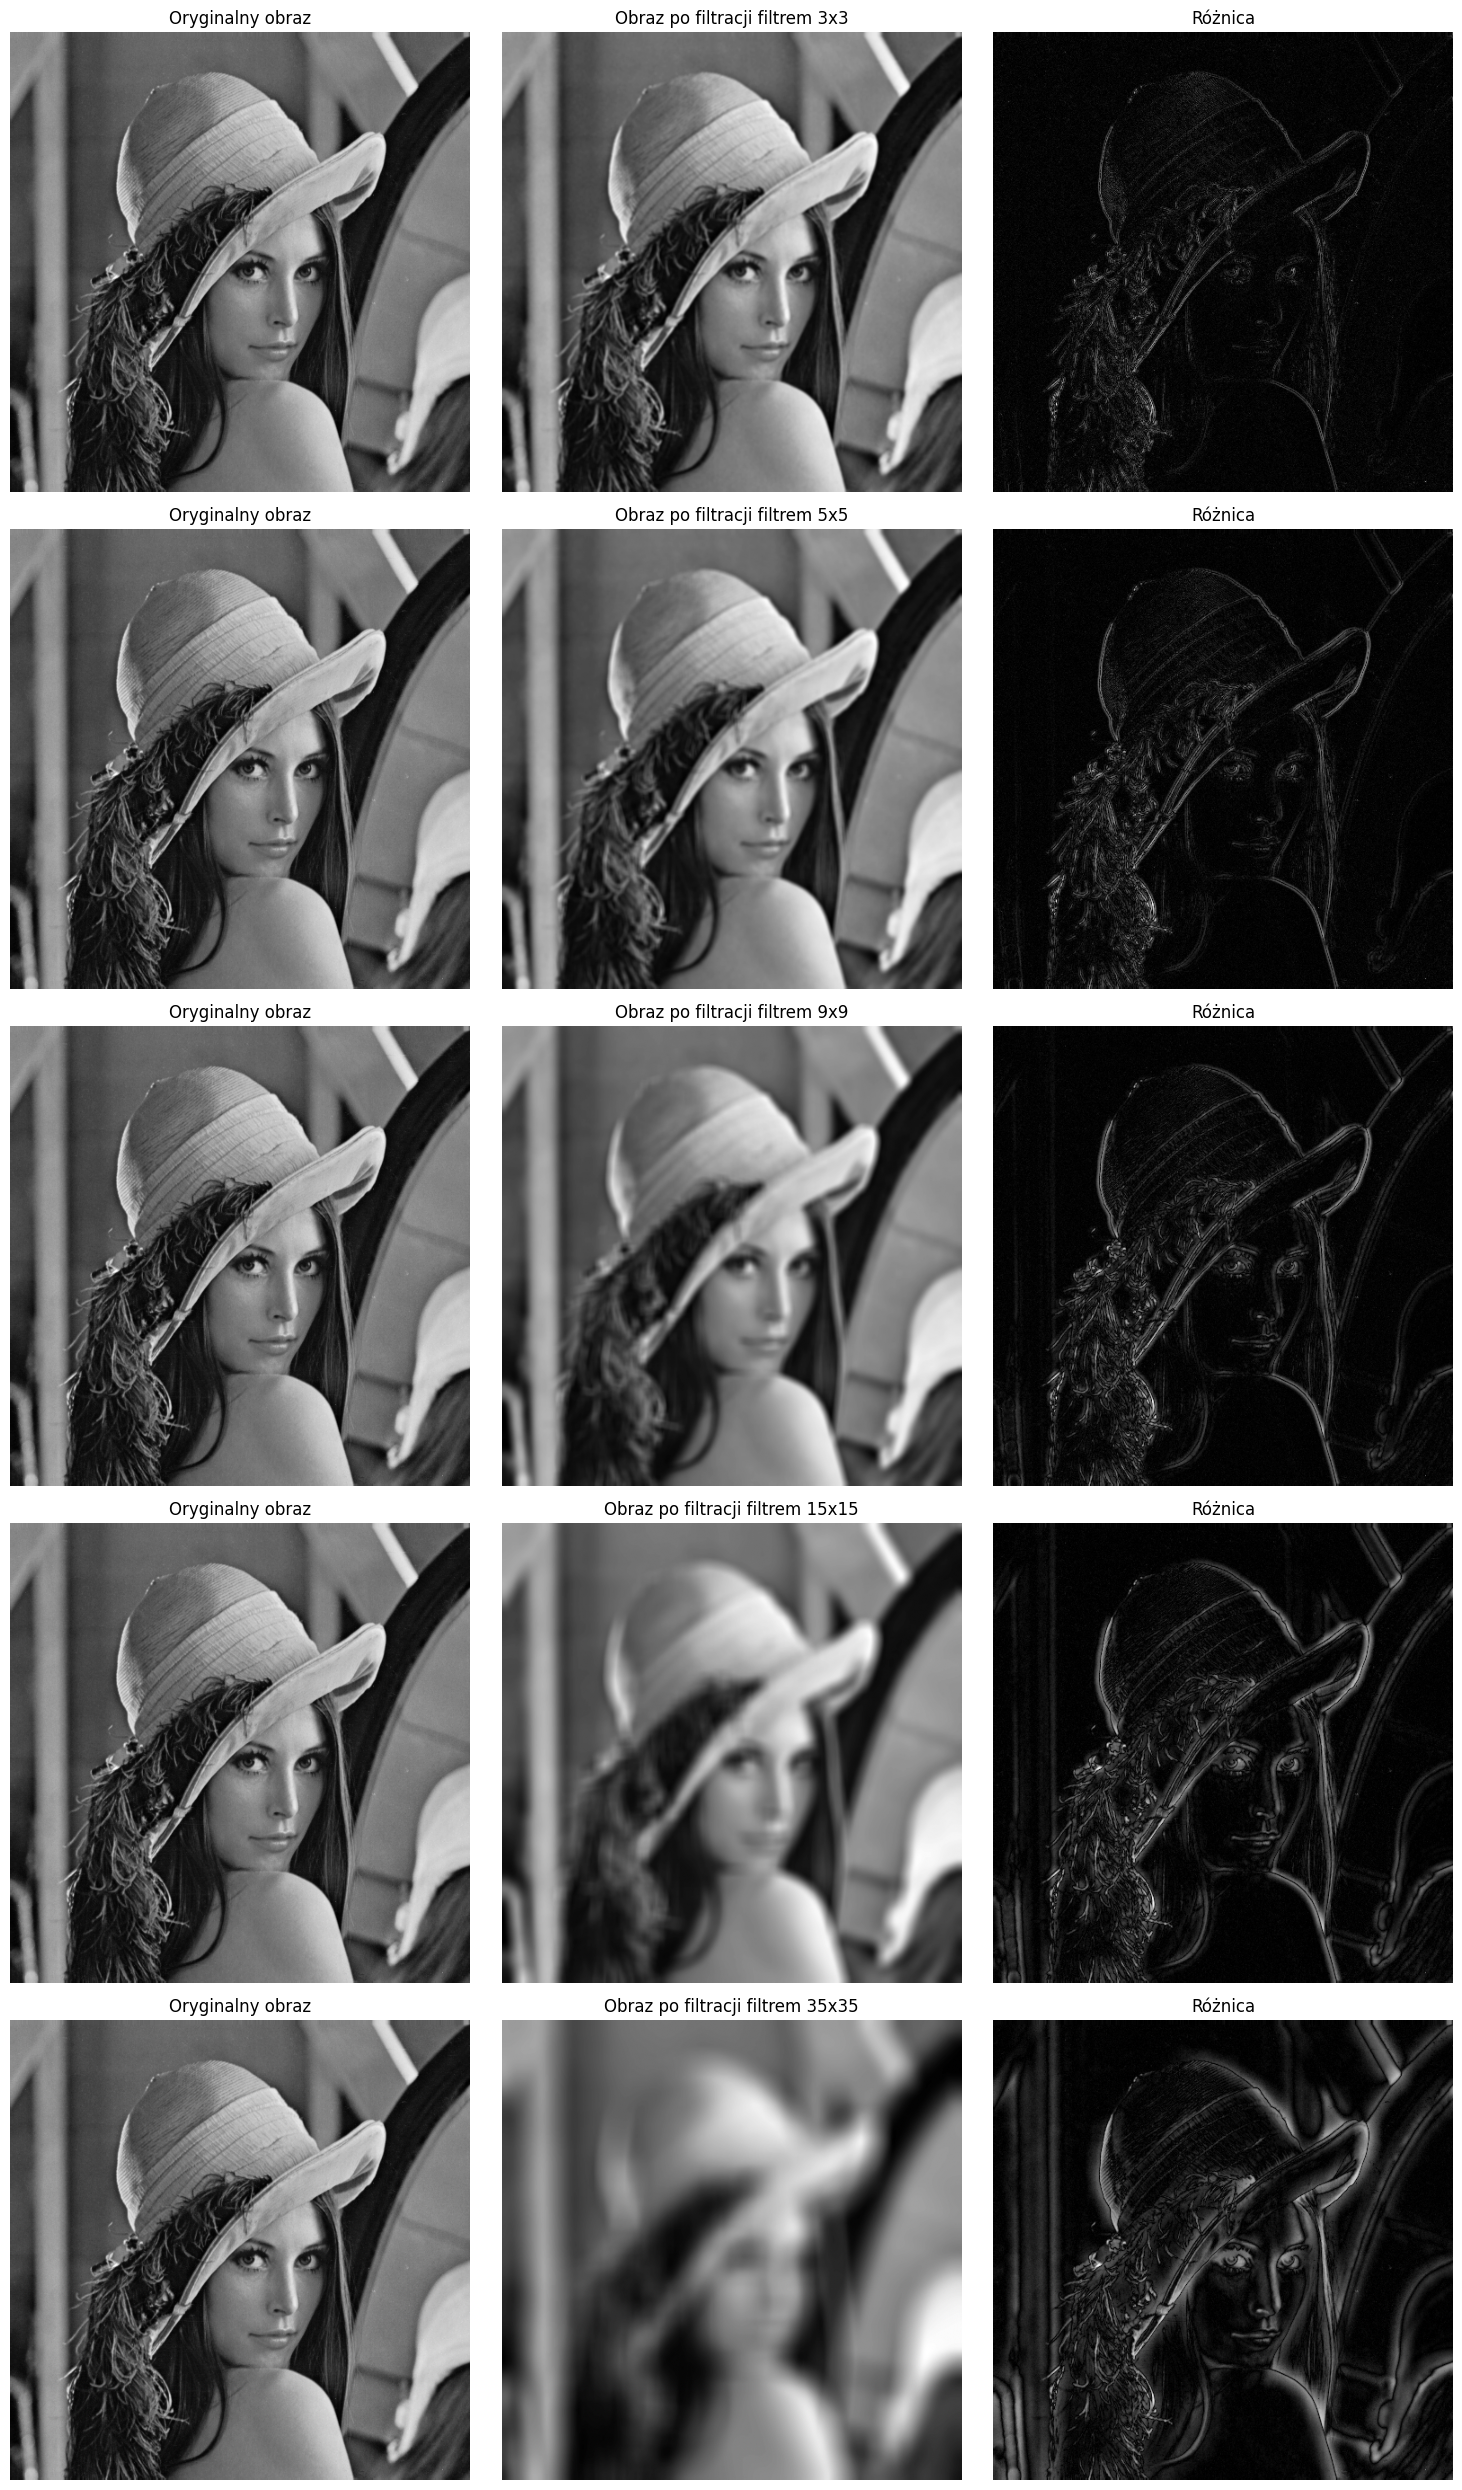

In [123]:
lena = cv2.imread('lena.png', cv2.IMREAD_GRAYSCALE).astype(np.int16)
plot_filtered_images(lena, kernel_sizes)

7. Niekorzystny efekt towarzyszący wykonanym filtracjom dolnoprzepustowym to utrata ostrości.
Częściowo można go zniwelować poprzez odpowiedni dobór maski.
Wykorzystaj maskę:  `M = np.array([1 2 1; 2 4 2; 1 2 1])`.
Przed obliczeniami należy jeszcze wykonać normalizację - podzielić każdy element maski przez sumę wszystkich elementów: `M = M/sum(sum(M));`.
Tak przygotowaną maskę wykorzystaj w konwolucji - wyświetl wyniki tak jak wcześniej.
Możliwe jest też wykorzystywanie innych masek - współczynniki można dopasowywać do konkretnego problemu.

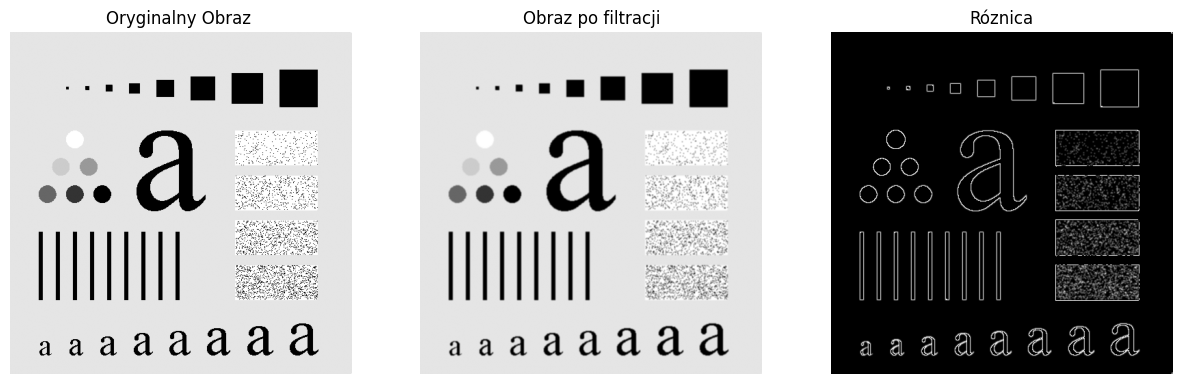

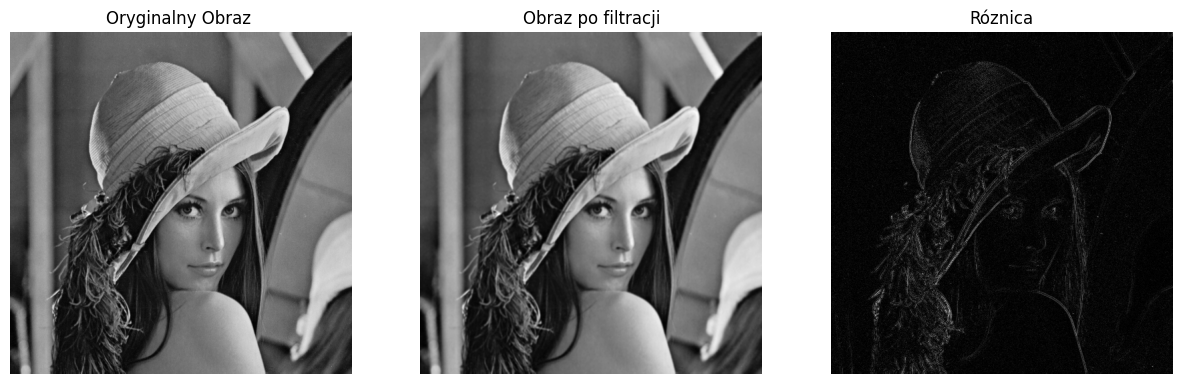

In [124]:
M = np.array([[1,2,1],
              [2,4,2],
              [1,2,1]])
M = M/sum(sum(M))

def test(img, M):
  img_filtered = cv2.filter2D(img, -1, M)
  img_diff = np.abs(img - img_filtered)

  plt.figure(figsize=(15,10))
  plt.subplot(1, 3, 1)
  plt.imshow(img, cmap='gray')
  plt.axis("off")
  plt.title("Oryginalny Obraz ")

  plt.subplot(1, 3, 2)
  plt.imshow(img_filtered, cmap='gray')
  plt.axis('off')
  plt.title("Obraz po filtracji")

  plt.subplot(1,3,3)
  plt.imshow(img_diff, cmap='gray')
  plt.axis('off')
  plt.title('Róznica')
test(plansza, M)
test(lena, M)

8. Skuteczną i często wykorzystywaną maską jest tzw. maska Gasussa.
Jest to zbiór liczb, które aproksymują dwuwymiarowy rozkład Gaussa.
Parametrem jest odchylenie standardowe i rozmiar maski.

9. Wykorzystując przygotowaną funkcję `fgaussian` stwórz maskę o rozmiarze $5 \times 5$ i odchyleniu standardowym 0.5.
  Wykorzystując funkcję `mesh` zwizualizuj filtr.
  Sprawdź jak parametr ``odchylenie standardowe'' wpływa na ``kształt'' filtru.

  Uwaga. W OpenCV dostępna jest *dedykowana* funkcja do filtracji Gaussa - `GaussianBlur`.
  Proszę na jednym przykładzie porównać jej działanie z użytym wyżej rozwiązaniem.

10. Wykonaj filtrację dla wybranych (2--3) wartości odchylenia standardowego.


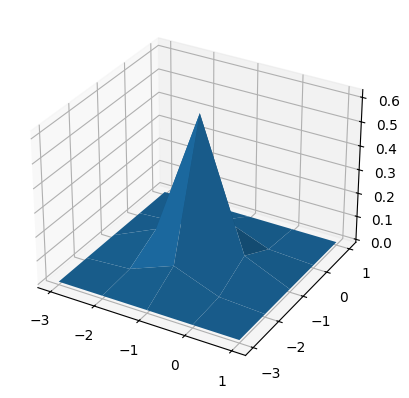

In [125]:
def fgaussian(size, sigma):
     m = n = size
     h, k = m//2, n//2
     x, y = np.mgrid[-h:h+1, -k:k+1]
     g = np.exp(-(x**2 + y**2)/(2*sigma**2))
     return g /g.sum()


def mesh(fun, size):
    fig = plt.figure()
    ax = fig.add_subplot(projection = '3d')


    X = np.arange(-size//2, size//2, 1)
    Y = np.arange(-size//2, size//2, 1)
    X, Y = np.meshgrid(X, Y)
    Z = fun
    ax.plot_surface(X, Y, Z)
    plt.show()

gaussian_mask = fgaussian(5, 0.5)
mesh(gaussian_mask, 5)




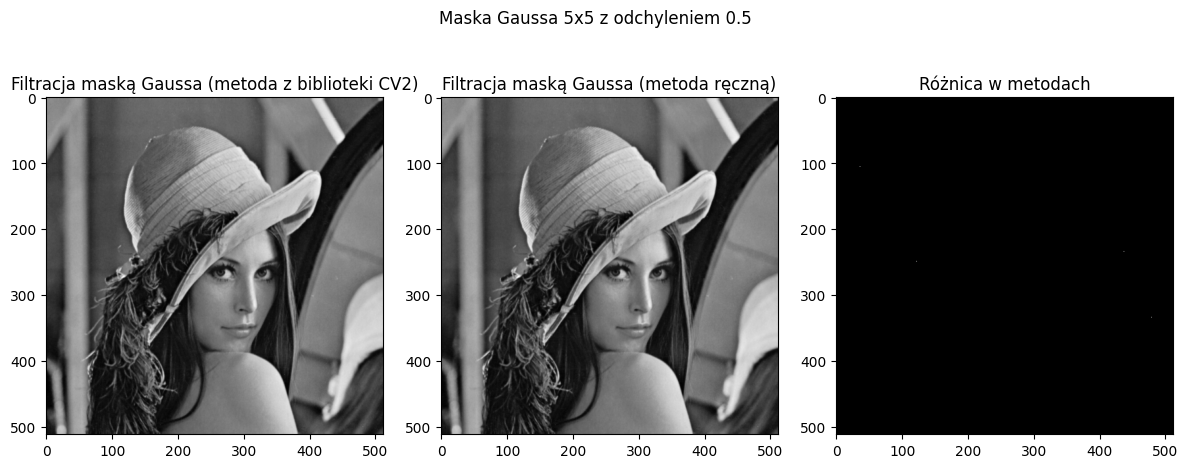

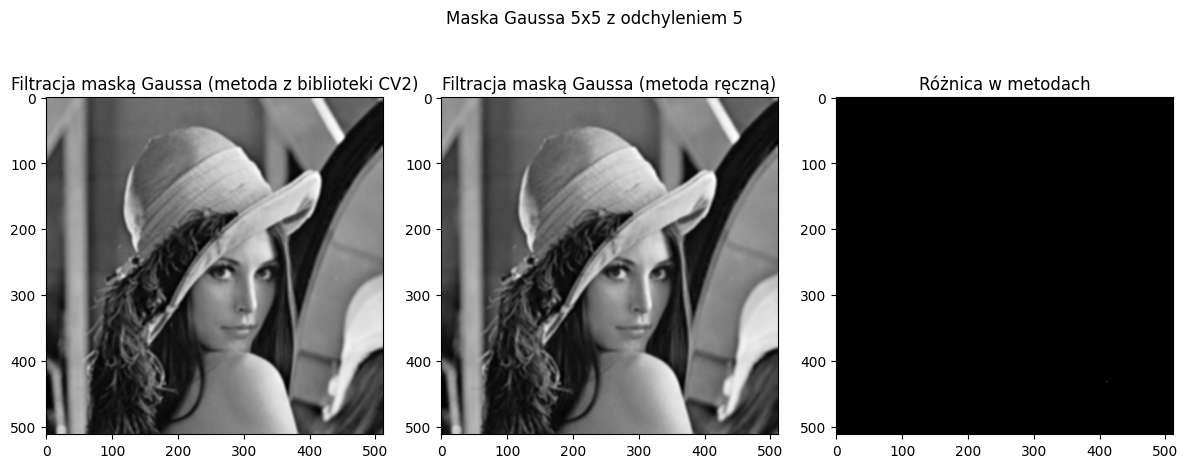

In [126]:
def plot_gassian_blur(img, size, sigma):
  mask = fgaussian(size, sigma)
  img_gaussian_lib = cv2.GaussianBlur(img, (size, size), sigma)
  img_gaussian_imp = cv2.filter2D(img, -1, mask)
  diff = abs(img_gaussian_lib - img_gaussian_imp)
  plt.figure(figsize=(12,5))
  plt.suptitle(f"Maska Gaussa {size}x{size} z odchyleniem {sigma}")
  plt.subplot(1, 3, 1)
  plt.imshow(img_gaussian_lib, cmap='gray')
  plt.title("Filtracja maską Gaussa (metoda z biblioteki CV2)")
  plt.subplot(1, 3, 2)
  plt.imshow(img_gaussian_imp, cmap='gray')
  plt.title('Filtracja maską Gaussa (metoda ręczną)')
  plt.subplot(1, 3, 3)
  plt.imshow(diff, cmap='gray')
  plt.title('Różnica w metodach')
  plt.tight_layout()

plot_gassian_blur(lena, 5, 0.5)
plot_gassian_blur(lena, 5, 5)

### Filtry nieliniowe -- mediana

Filtry rozmywające redukują szum, ale niekorzystnie wpływają na ostrość obrazu.
Dlatego często wykorzystuje się filtry nieliniowe - np. filtr medianowy (dla przypomnienia: mediana - środkowa wartość w posortowanym ciągu liczb).

Podstawowa różnica pomiędzy filtrami liniowymi, a nieliniowymi polega na tym, że przy filtracji liniowej na nową wartość piksela ma wpływ wartość wszystkich pikseli z otoczenia (np. uśrednianie, czasem ważone), natomiast w przypadku filtracji nieliniowej jako nowy piksel wybierana jest któraś z wartości otoczenia - według jakiegoś wskaźnika (wartość największa, najmniejsza czy właśnie mediana).


1. Wczytaj obraz _lenaSzum.png_ (losowe 10% pikseli białych lub czarnych - tzw. zakłócenia impulsowe). Przeprowadź filtrację uśredniającą z rozmiarem maski 3x3. Wyświetl, podobnie jak wcześniej, oryginał, wynik filtracji i moduł z różnicy. Wykorzystując funkcję ``cv2.medianBlur` wykonaj filtrację medianową _lenaSzum.png_ (z rozmiarem maski $3 \times 3$). Wyświetl, podobnie jak wcześniej, oryginał, wynik filtracji i moduł z różnicy. Która filtracja lepiej radzi sobie z tego typu szumem?

  Uwaga. Taki sam efekt da również użycie funkcji `signal.medfilt2d`.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

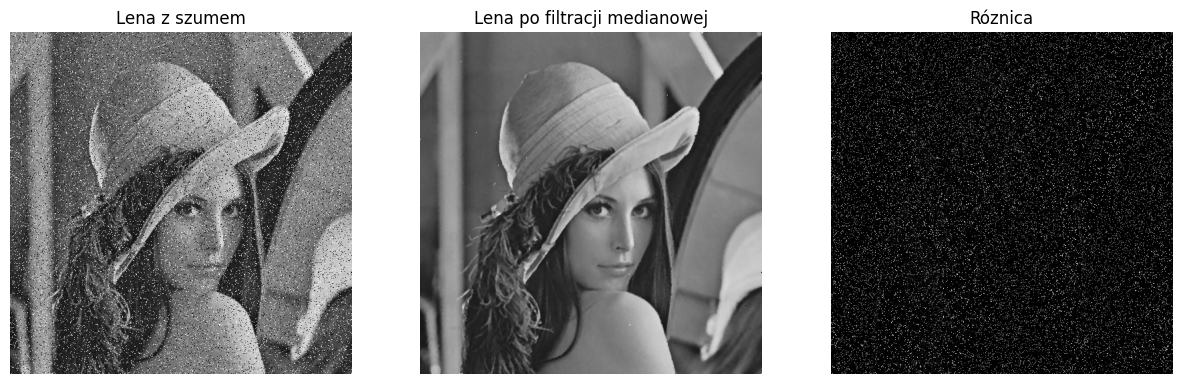

In [127]:
lena_noise = cv2.imread("lenaSzum.png", cv2.IMREAD_GRAYSCALE).astype(np.int16)
lena_noise_reduced = cv2.medianBlur(lena_noise, 3)
lena_noise_diff = abs(lena_noise - lena_noise_reduced)

plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
plt.imshow(lena_noise, cmap='gray')
plt.title("Lena z szumem")
plt.axis("Off")

plt.subplot(1,3,2)
plt.imshow(lena_noise_reduced, cmap='gray')
plt.title("Lena po filtracji medianowej")
plt.axis("Off")

plt.subplot(1,3,3)
plt.imshow(lena_noise_diff, cmap='gray')
plt.title("Róznica")
plt.axis("Off")


2. Przeprowadź filtrację uśredniającą, a następnie medianową obrazu _lena.png_.
   Wyniki porównaj - dla obu wyświetl: oryginał, wynik filtracji i moduł z różnicy.
   Szczególną uwagę zwróć na ostrość i krawędzie.
   W której filtracji krawędzie zostają lepiej zachowane?

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

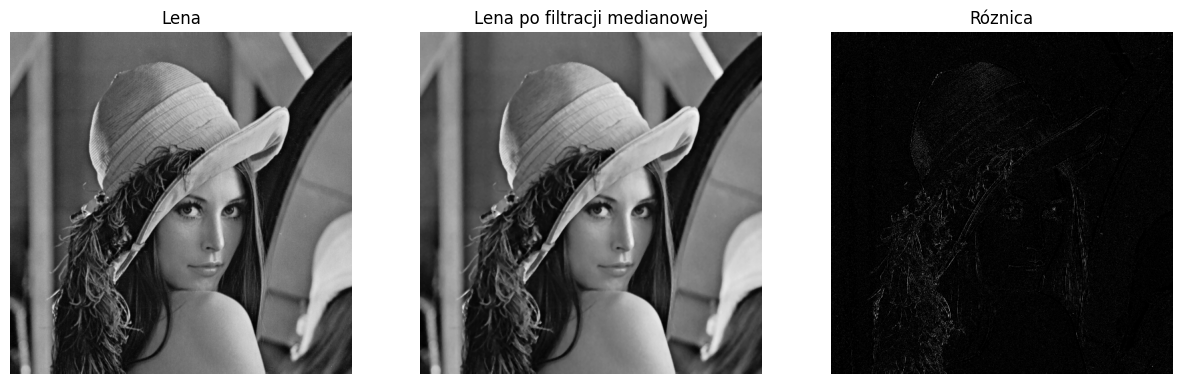

In [128]:
lena_reduced = cv2.medianBlur(lena, 3)
lena_diff = abs(lena - lena_reduced)

plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
plt.imshow(lena, cmap='gray')
plt.title("Lena")
plt.axis("Off")

plt.subplot(1,3,2)
plt.imshow(lena_reduced, cmap='gray')
plt.title("Lena po filtracji medianowej")
plt.axis("Off")

plt.subplot(1,3,3)
plt.imshow(lena_diff, cmap='gray')
plt.title("Róznica")
plt.axis("Off")

3. Ciekawy efekt można uzyskać wykonując filtrację medianową wielokrotnie. Określa się go mianem  posteryzacji.  W wyniku przetwarzania z obrazka usunięte zostają detale, a duże obszary uzyskują tą samą wartość jasności.  Wykonaj operację mediany $5 \times 5$ na obrazie _lena.png_ 10-krotnie. (wykorzystaj np. pętlę `for`).


Inne filtry nieliniowe:
- filtr modowy - moda (dominanta) zamiast mediany,
- filtr olimpijski - średnia z podzbioru otoczenia (bez wartości ekstremalnych),
- hybrydowy filtr medianowy - mediana obliczana osobno w różnych podzbiorach otoczenia (np. kształt ``x'',``+''), a jako wynik brana jest mediana ze zbioru wartość elementu centralnego, mediana z ``x'' i mediana z ``+'',
- filtr minimalny i maksymalny (będą omówione przy okazji operacji morfologicznych w dalszej części kursu).


Warto zdawać sobie sprawę, z szerokich możliwości dopasowywania rodzaju filtracji do konkretnego rozważanego problemu i rodzaju zaszumienia występującego na obrazie.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

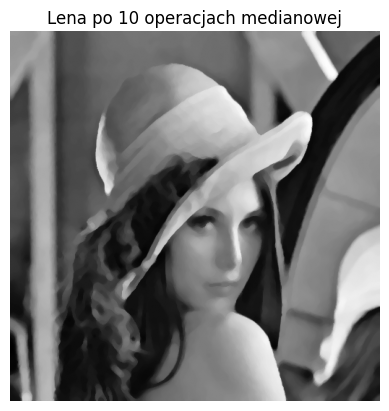

In [129]:
# operacja mediany 10 krotnie

for i in range(10):
  lena_noise = cv2.medianBlur(lena_noise, 5)
plt.imshow(lena_noise, cmap='gray')
plt.title("Lena po 10 operacjach medianowej")
plt.axis("Off")

## Filtry liniowe górnoprzepustowe (wyostrzające, wykrywające krawędzie)

Zadaniem filtrów górnoprzepustowych jest wydobywanie z obrazu składników odpowiedzialnych za szybkie zmiany jasności - konturów, krawędzi, drobnych elementów tekstury.

### Laplasjan (wykorzystanie drugiej pochodnej obrazu)

1. Wczytaj obraz _moon.png_.

2. Wprowadź podstawową maskę laplasjanu:
\begin{equation}
M =
\begin{bmatrix}
0 & 1& 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0
\end{bmatrix}
\end{equation}

3. Przed rozpoczęciem obliczeń należy dokonać normalizacji maski - dla rozmiaru $3 \times 3$ podzielić każdy element przez 9.
   Proszę zwrócić uwagę, że nie można tu zastosować takiej samej normalizacji, jak dla filtrów dolnoprzepustowanych, gdyż skutkowałby to dzieleniem przez 0.

4. Wykonaj konwolucję obrazu z maską (`c2.filter2D`). Przed wyświetleniem, wynikowy obraz należy poddać normalizacji (występują ujemne wartości). Najczęściej wykonuje się jedną z dwóch operacji:
- skalowanie (np. poprzez dodatnie 128 do każdego z pikseli),
- moduł (wartość bezwzględna).

Wykonaj obie normalizacje.
Na wspólnym wykresie wyświetl obraz oryginalny oraz przefiltrowany po obu normalizacjach.

Text(0.5, 1.0, 'Wartość bezwzględna')

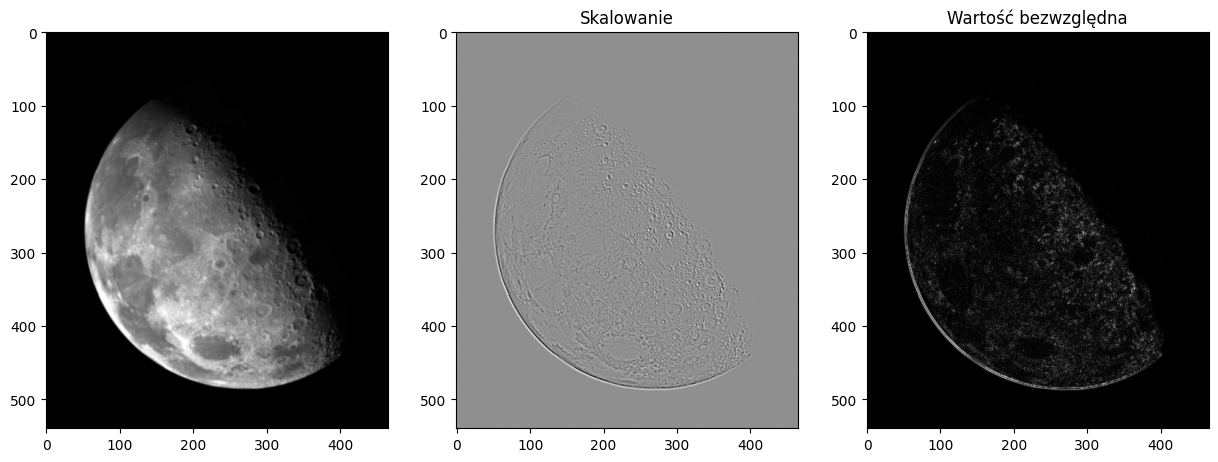

In [130]:
moon = cv2.imread("moon.png", cv2.IMREAD_GRAYSCALE)
M = np.array([[0,1,0],
              [1,-4,1],
              [0,1,0]])
M_norm = M/9
moon = moon.astype(np.float64)
moon_filtered = cv2.filter2D(moon, -1, M)
moon_scaled = moon_filtered + 128
moon_scaled = np.clip(moon_scaled, 0, 255).astype(np.uint8)
moon_abs = np.abs(moon_filtered)
moon_abs = np.clip(moon_abs, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(moon, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(moon_scaled, cmap='gray')
plt.title("Skalowanie")
plt.subplot(1, 3, 3)
plt.imshow(moon_abs, cmap='gray')
plt.title('Wartość bezwzględna')


7. Efekt wyostrzenia uzyskuje się po odjęciu/dodaniu (zależy do maski) rezultatu filtracji laplasjanowej i oryginalnego obrazu. Wyświetl na jednym wykresie: obraz oryginalny, sumę oryginału i wyniku filtracji oraz różnicę (bezwzględną) oryginału i wyniku filtracji.
 Uwaga. Aby uniknąć artefaktów, należy obraz wejściowy przekonwertować do formatu ze znakiem.



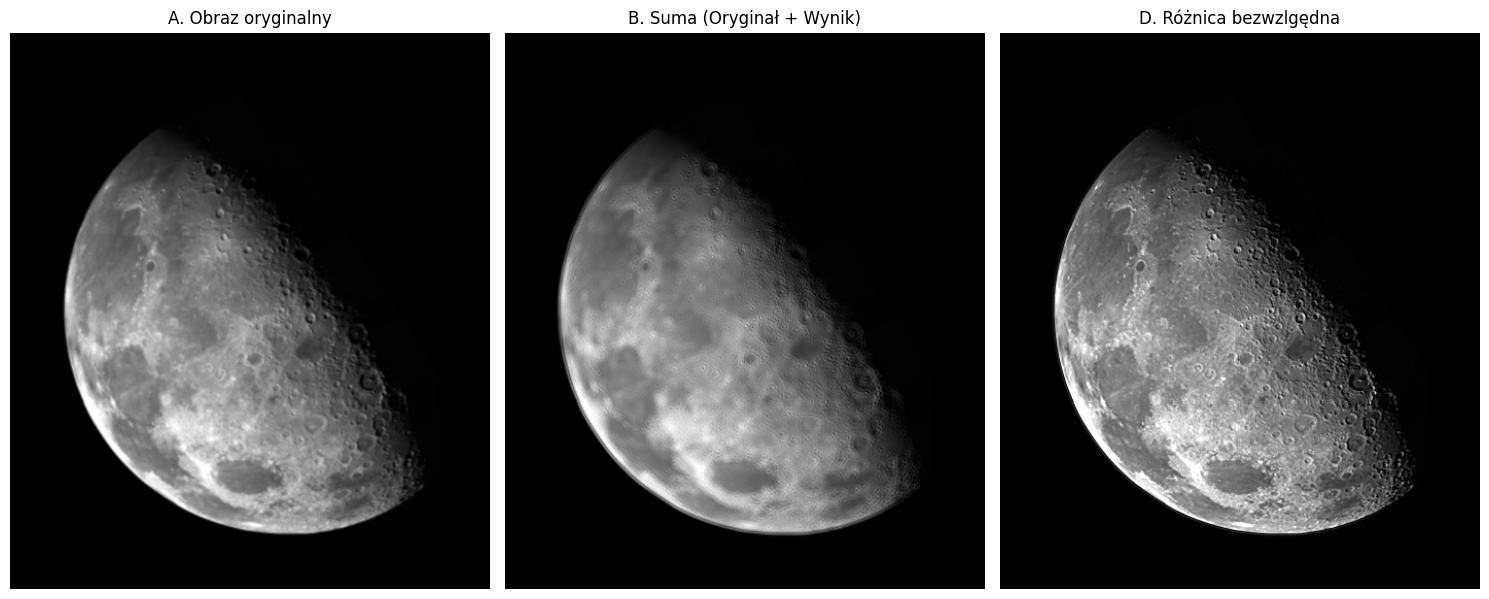

In [131]:
sharp_add = moon + moon_filtered
sharp_add_u8 = np.clip(sharp_add, 0, 255).astype(np.uint8)

sharp_abs_diff = np.abs(moon - moon_filtered)
sharp_abs_diff_u8 = np.clip(sharp_abs_diff, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(moon, cmap='gray')
plt.title("A. Obraz oryginalny")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp_add_u8, cmap='gray')
plt.title("B. Suma (Oryginał + Wynik)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharp_abs_diff_u8, cmap='gray')
plt.title("D. Różnica bezwzlgędna")
plt.axis('off')

plt.tight_layout()
plt.show()

### Gradienty (wykorzystanie pierwszej pochodnej obrazu)

1. Wczytaj obraz _kw.png_. Stwórz odpowiednie maski opisane w kolejnych punktach i dokonaj filtracji.
2. Wykorzystując gradient Robertsa przeprowadź detekcję krawędzi - poprzez wykonanie konwolucji obrazu z daną maską:
\begin{equation}
R1 = \begin{bmatrix} 0 & 0 & 0 \\ -1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}   
R2 = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{bmatrix}
\end{equation}

Wykorzystaj stworzony wcześniej kod (przy laplasjanie) - dwie metody normalizacji oraz sposób wyświetlania.

3. Analogicznie przeprowadź detekcję krawędzi za pomocą gradientu Prewitta (pionowy i poziomy)
\begin{equation}
P1 = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}   
P2 = \begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ 1 & 1 & 1 \end{bmatrix}
\end{equation}

4. Podobnie skonstruowany jest gradient Sobela (występuje osiem masek, zaprezentowane są dwie ``prostopadłe''):
\begin{equation}
S1 = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}   
S2 = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
\end{equation}

Przeprowadź detekcję krawędzi za pomocą gradientu Sobela.

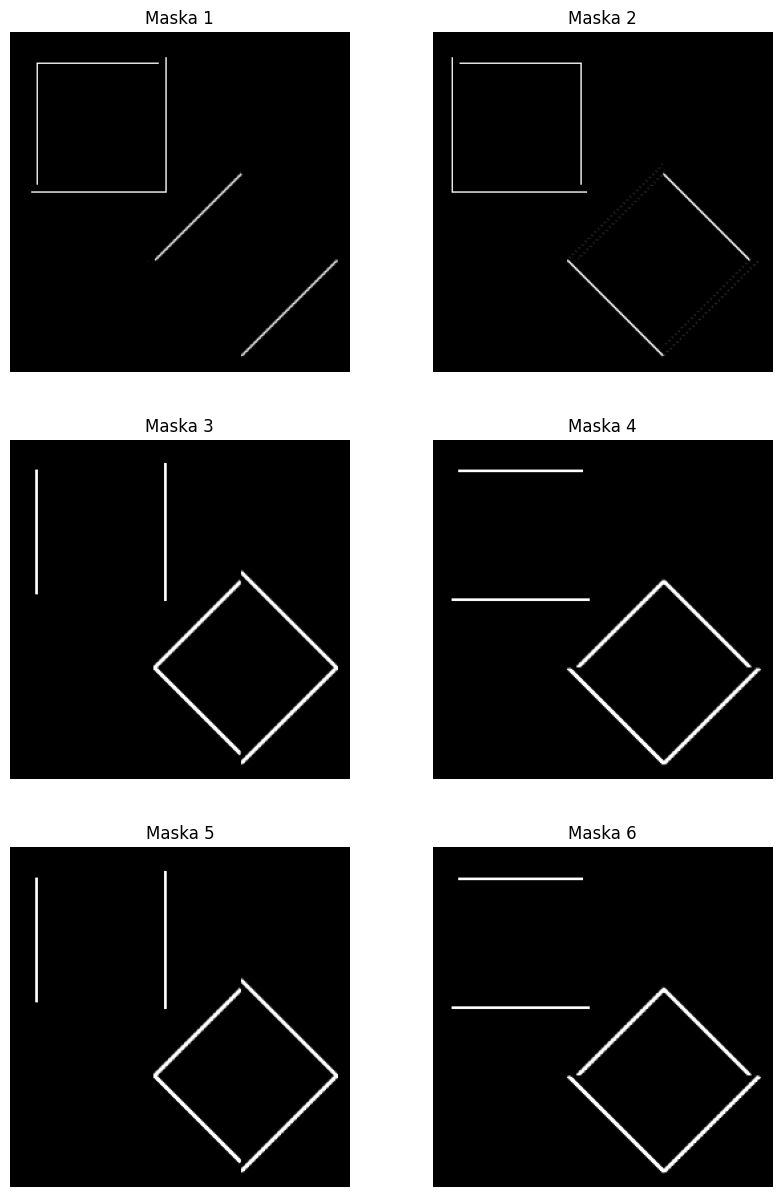

In [132]:
kw = cv2.imread('kw.png', cv2.IMREAD_GRAYSCALE)
#maski
R1 = np.array([[0,0,0],
              [-1,0,0],
              [0,1,0]])
R2 = np.array([[0,0,0],
              [0,0,-1],
              [0,1,0]])
P1 = np.array([[-1,0,1],
              [-1,0,1],
              [-1,0,1]])
P2 = np.array([[-1, -1, -1],
              [0,0,0],
              [1,1,1]])
S1 = np.array([[-1,0,1],
              [-2,0,2],
              [-1,0,1]])
S2 = np.array([[-1,-2,-1],
              [0,0,0],
              [1,2,1]])
masks = [R1, R2, P1, P2, S1, S2]

plt.figure(figsize=(10,15))
for i, mask in enumerate(masks):
  kw_filtered = cv2.filter2D(kw, -1, mask)
  kw_filtered = np.clip(kw_filtered, 0, 255).astype(np.uint8)
  plt.subplot(3, 2, i+1)
  plt.imshow(kw_filtered, cmap='gray')
  plt.title(f"Maska {i+1}")
  plt.axis('off')

5. Na podstawie dwóch ortogonalnych masek np. Sobela można stworzyć tzw. filtr kombinowany - pierwiastek kwadratowy z sumy kwadratów gradientów:
\begin{equation}
OW = \sqrt{(O * S1)^2 + (O * S2)^2}
\end{equation}
gdzie:  $OW$ - obraz wyjściowy, $O$ - obraz oryginalny (wejściowy), $S1,S2$ - maski Sobela, $*$ - operacja konwolucji.

Zaimplementuj filtr kombinowany.

Uwaga. Proszę zwrócić uwagę na konieczność zmiany formatu danych obrazu wejściowego - na typ znakiem



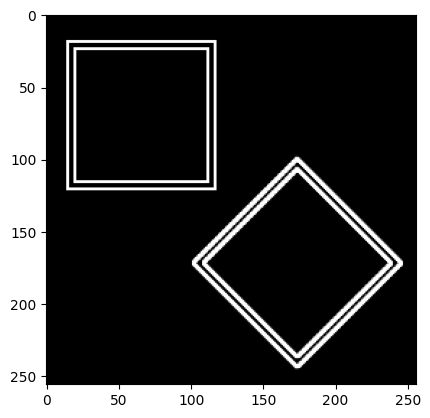

In [133]:
kw = kw.astype(np.float64)

filtered1 = cv2.filter2D(kw, -1, S1)
filtered2 = cv2.filter2D(kw, -1, S2)

output_img = np.sqrt(np.square(filtered1) + np.square(filtered2))
output_img = np.clip(output_img, 0, 255).astype(np.uint8)
plt.imshow(output_img, cmap='gray')

6. Istnieje alternatywna wersja filtra kombinowanego, która zamiast pierwiastka z sumy kwadratów wykorzystuje sumę modułów (prostsze obliczenia).
Zaimplementuj tę wersję.

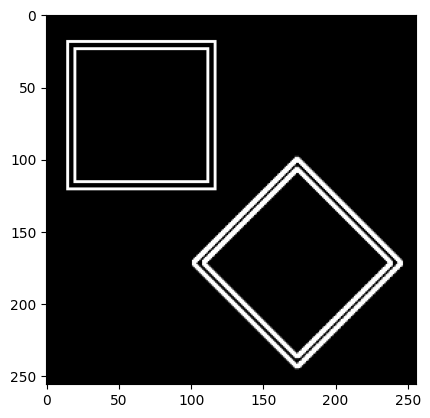

In [134]:
output_img2 = np.abs(filtered1) + np.abs(filtered2)
output_img2 = np.clip(output_img2, 0, 255).astype(np.uint8)
plt.imshow(output_img2, cmap='gray')

7. Wczytaj plik _jet.png_ (zamiast _kw.png_).
Sprawdź działanie obu wariantów filtracji kombinowanej.

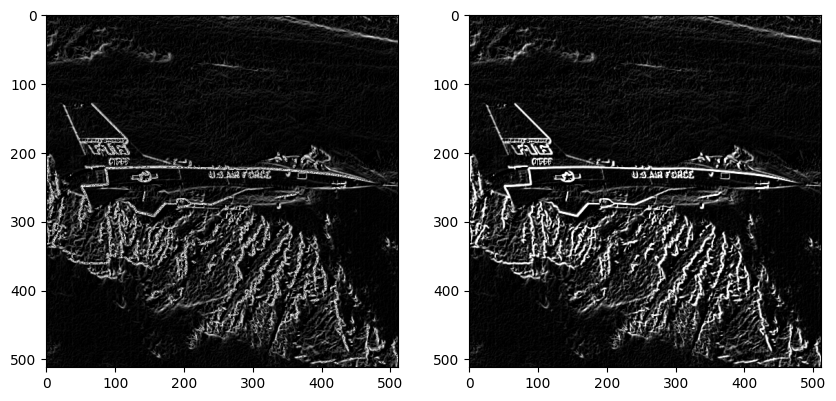

In [135]:
jet = cv2.imread("jet.png", cv2.IMREAD_GRAYSCALE).astype(np.uint16)
sqrt_img = np.sqrt(np.square(cv2.filter2D(jet, -1, S1)) + np.square(cv2.filter2D(jet, -1, S2)))
sqrt_img = np.clip(sqrt_img, 0, 255).astype(np.uint8)

abs_img = np.abs(cv2.filter2D(jet, -1, S1)) + np.abs(cv2.filter2D(jet, -1, S2))
abs_img = np.clip(abs_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(sqrt_img, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(abs_img, cmap='gray')